# **Supply Chain Analysis for E-commerce Retail Platform**

## **IMPORT LIBRARIES**
pandas (pd) → used to handle tabular data (like Excel)
numpy (np) → used for random number generation & calculations
matplotlib.pyplot (plt) → used for plotting graphs
seaborn (sns) → advanced visualization library

👉 sns.set_style("whitegrid")

Adds background grid to graphs → makes charts cleaner and readable

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## **LOAD DATA**
pd.read_csv(...)
Loads CSV file into DataFrame (df)
df.head()
Displays first 5 rows
👉 Used to visually check if data loaded correctly
df.info()

Shows:

Total rows → 27,555
Columns → 10
Data types (int, float, object)
Missing values

👉 Important observation:

rating has missing values
product and brand also have some nulls

In [2]:
df = pd.read_csv("BigBasket Products.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27555 entries, 0 to 27554
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         27555 non-null  int64  
 1   product       27554 non-null  object 
 2   category      27555 non-null  object 
 3   sub_category  27555 non-null  object 
 4   brand         27554 non-null  object 
 5   sale_price    27555 non-null  float64
 6   market_price  27555 non-null  float64
 7   type          27555 non-null  object 
 8   rating        18929 non-null  float64
 9   description   27440 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 2.1+ MB


## **DATA CLEANING**

In [3]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df['rating'] = df['rating'].fillna(df['rating'].mean())

df = df.drop_duplicates()

## **FEATURE ENGINEERING**
* Fixes randomness → same output every time
*   Creates unique ID for each row (order simulation)
*   Random values between 1–9
* Simulates number of items per order
* Creates realistic order dates across a year
* Simulates geographic demand
* Business metric
* Simulates stock available
* Converts numeric stock → business category







In [4]:
np.random.seed(42)

df['order_id'] = range(1000, 1000 + len(df))
df['quantity'] = np.random.randint(1, 10, len(df))

df['order_date'] = pd.to_datetime('2023-01-01') + pd.to_timedelta(np.random.randint(0, 365, len(df)), unit='d')

df['city'] = np.random.choice(['Surat','Mumbai','Delhi','Bangalore'], len(df))

df['total_sales'] = df['quantity'] * df['sale_price']

df['delivery_days'] = np.random.randint(1, 8, len(df))

df['inventory_level'] = np.random.randint(0, 100, len(df))

def stock_status(x):
    if x == 0:
        return "Out of Stock"
    elif x < 20:
        return "Low Stock"
    else:
        return "In Stock"

df['stock_status'] = df['inventory_level'].apply(stock_status)

## **CATEGORY SALES VISUAL**
* Groups data by category
* Calculates total revenue per category
* Sorts values
* Creates horizontal bar chart
* Displays chart

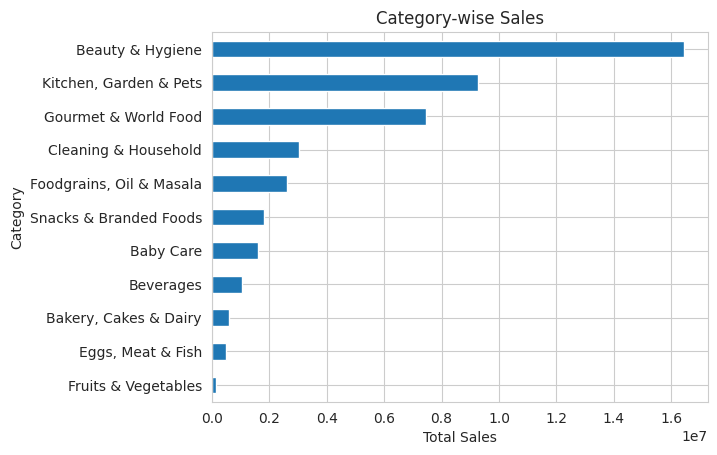

In [5]:
category_sales = df.groupby('category')['total_sales'].sum().sort_values()

plt.figure()
category_sales.plot(kind='barh')
plt.title("Category-wise Sales")
plt.xlabel("Total Sales")
plt.ylabel("Category")
plt.show()

## **CITY DEMAND**
* Calculates total quantity sold per city
* Bar chart

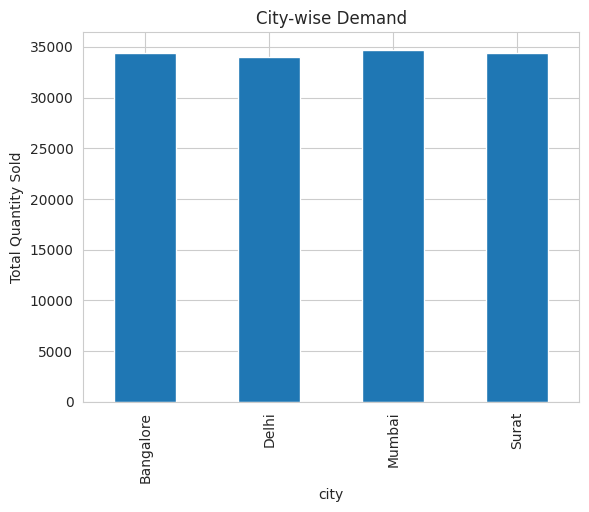

In [8]:
city_demand = df.groupby('city')['quantity'].sum()

plt.figure()
city_demand.plot(kind='bar')
plt.title("City-wise Demand")
plt.ylabel("Total Quantity Sold")
plt.show()

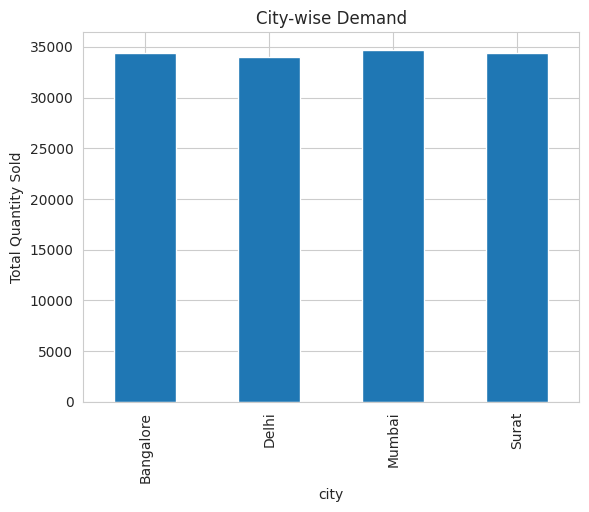

In [9]:
city_demand = df.groupby('city')['quantity'].sum()

plt.figure()
city_demand.plot(kind='bar')
plt.title("City-wise Demand")
plt.ylabel("Total Quantity Sold")
plt.show()

## **INVENTORY PIE CHART**
Counts:

* In Stock
* Low Stock
* Out of Stock

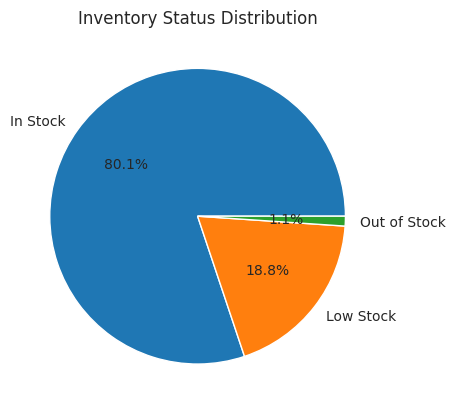

In [10]:
stock_counts = df['stock_status'].value_counts()

plt.figure()
stock_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Inventory Status Distribution")
plt.ylabel("")
plt.show()

## **TOP PRODUCTS**
* Top 10 products by revenue




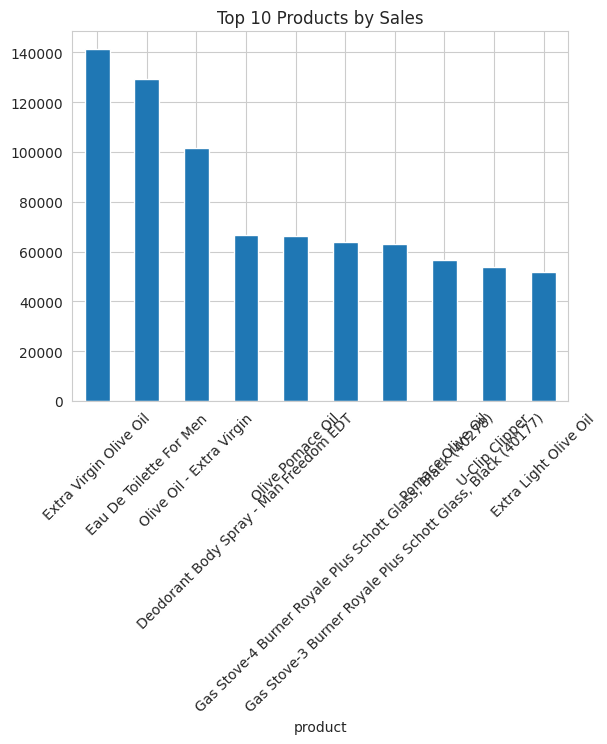

In [11]:
top_products = df.groupby('product')['total_sales'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products.plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.xticks(rotation=45)
plt.show()

## **KPI SECTION**
* Total revenue
* Avg delivery time
* Total orders
* Stockout rate

In [12]:
print("Total Revenue:", df['total_sales'].sum())
print("Average Delivery Time:", df['delivery_days'].mean())
print("Total Orders:", df['order_id'].nunique())
print("Stockout Rate:", len(df[df['stock_status']=='Out of Stock'])/len(df))

Total Revenue: 44553526.169999994
Average Delivery Time: 3.9938305207766285
Total Orders: 27555
Stockout Rate: 0.010669569951007077


## **SQL SETUP**
* Creates temporary SQL database
* Converts DataFrame → SQL table

In [13]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('sales_data', conn, index=False, if_exists='replace')

27555

## **QUERY 1**
* Top 5 products by revenue

In [14]:
query1 = """
SELECT product, SUM(total_sales) AS revenue
FROM sales_data
GROUP BY product
ORDER BY revenue DESC
LIMIT 5;
"""

pd.read_sql(query1, conn)


,product,revenue
0,Extra Virgin Olive Oil,141335.71
1,Eau De Toilette For Men,129105.00
2,Olive Oil - Extra Virgin,101732.66
3,Deodorant Body Spray - Man Freedom EDT,66600.00
4,Olive Pomace Oil,66187.25


## **QUERY 2**
* Category-wise revenue

In [15]:
query2 = """
SELECT category, SUM(total_sales) AS total_revenue
FROM sales_data
GROUP BY category
ORDER BY total_revenue DESC;
"""

pd.read_sql(query2, conn)

,category,total_revenue
0,Beauty & Hygiene,16440083.33
1,"Kitchen, Garden & Pets",9268099.26
2,Gourmet & World Food,7461110.32
3,Cleaning & Household,3031810.83
4,"Foodgrains, Oil & Masala",2622755.07
5,Snacks & Branded Foods,1808079.86
6,Baby Care,1622985.92
7,Beverages,1061065.13
8,"Bakery, Cakes & Dairy",586338.34
9,"Eggs, Meat & Fish",507985.81


## **QUERY 3**
* Category-wise revenue

In [16]:
query3 = """
SELECT city, COUNT(order_id) AS total_orders
FROM sales_data
GROUP BY city;
"""

pd.read_sql(query3, conn)

,city,total_orders
0,Bangalore,6952
1,Delhi,6759
2,Mumbai,6919
3,Surat,6925


## **EXPORT**
* Saves final dataset

In [17]:
df.to_csv("final_supply_chain_data.csv", index=False)